# **Gradient Descent**

Gradient Descent is an optimization technique. 

It is the backbone of entire deep learning.

## Linear Regression vs. Gradient Descent

It is common to confuse these two because they are often used together, but they are fundamentally different concepts.
| Feature | Linear Regression | Gradient Descent |
| :--- | :--- | :--- |
| **What is it?** | A statistical **Model** | An optimization **Algorithm** |
| **Analogy** | The **Car** | The **Engine** that moves the car |
| **Purpose** | Defines **what** we want to find (the best-fit line). | Defines **how** we find it (iterative improvement). |
| **Equation** | $y = mx + b$ | $m_{new} = m_{old} - \alpha \cdot \frac{\partial J}{\partial m}$ |

## 1. Linear Regression (The "What")
Linear regression is a problem statement. It says:
> "I have data points, and I want to find the straight line that is closest to all of them."
It defines the **Cost Function** (usually Mean Squared Error), which measures how "wrong" a specific line is. It does **not** inherently specify how to find the best line, just that we want the one with the least error.

## 2. Gradient Descent (The "How")
Gradient Descent is a generic method used to minimize functions. When applied to Linear Regression, it acts as the "solver".

### How it works:
1.  **Start Randomly**: Pick a random slope ($m$) and intercept ($c$).
2.  **Check Error**: See how bad the line is (calculate the Cost).
3.  **Calculate Gradient**: Find out which direction to move $m$ and $c$ to reduce the error.
4.  **Take a Step**: Nudge $m$ and $b$ slightly in that direction.
5.  **Repeat**: Do this thousands of times until the error stops decreasing (convergence).
---

### Summary
*   You can solve Linear Regression **without** Gradient Descent (using the **Normal Equation** like `m = numerator / denominator`). This is fast for small data but slow for huge data.
*   You can use Gradient Descent for things **other than** Linear Regression (like Neural Networks, Logistic Regression, etc.).
**In short:** Linear Regression gives you the map and the destination. Gradient Descent is the act of walking step-by-step to get there.




## What happens if we don't use Gradient Descent?
If you don't use Gradient Descent, you solve Linear Regression using the **Normal Equation** (also known as the Closed-Form Solution or OLS - Ordinary Least Squares).

Instead of taking steps down a hill (iterative), you essentially "teleport" directly to the bottom using pure algebra and matrix math.

## The Normal Equation
Mathematics allows us to derive a direct formula to find the best parameters ($m$) in one single step:
$$ m = (X^T X)^{-1} X^T y $$

### Pros (Why you might prefer this)
1.  **No Iterations**: You get the answer instantly in one line of code.
2.  **Exact Solution**: It finds the mathematically precise global minimum, not just an approximation.
3.  **No Hyperparameters**: You don't need to pick a "Learning Rate" ($\alpha$) or worry about it being too big or too small.

### Cons (The "Catch")
1.  **Slow on Big Data**: The term $(X^T X)^{-1}$ requires computing the *inverse* of a matrix.
    *   If you have $n$ features (columns), the computational complexity is roughly **$O(n^3)$**.
    *   If you double your features, the calculation time increases by **8x**.
    *   For 100,000 features, this becomes computationally impossible for most computers.
    *   Simply linear regression without gradient descent will work slower in higher dimension data.
2.  **Memory Intensity**: Storing and inverting extremely large matrices consumes massive amounts of RAM.

## Summary Table
| Feature | Gradient Descent | Normal Equation (No Gradient Descent) |
| :--- | :--- | :--- |
| **Method** | Iterative (Step-by-step) | Analytical (Direct Formula) |
| **Speed** | Fast for large datasets | Slow for large datasets ($n > 10,000$) |
| **Accuracy** | Approximation (very close) | Exact |
| **Configuration** | Needs Learning Rate ($\alpha$) | No configuration needed |
| **Best For** | Deep Learning, Big Data | Small tabular datasets |




There are 3 types of gradient descent:
1. Batch Gradient Descent
2. Stochastic Gradient Descent  (SGD) [SGD regressor]
3. Mini-batch Gradient Descent

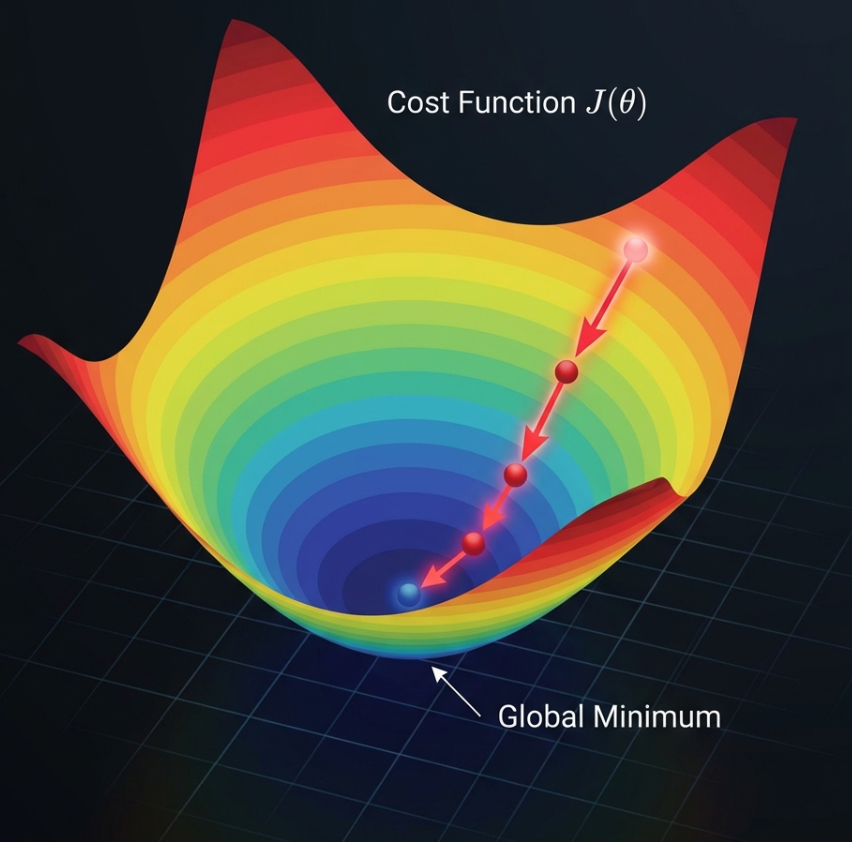

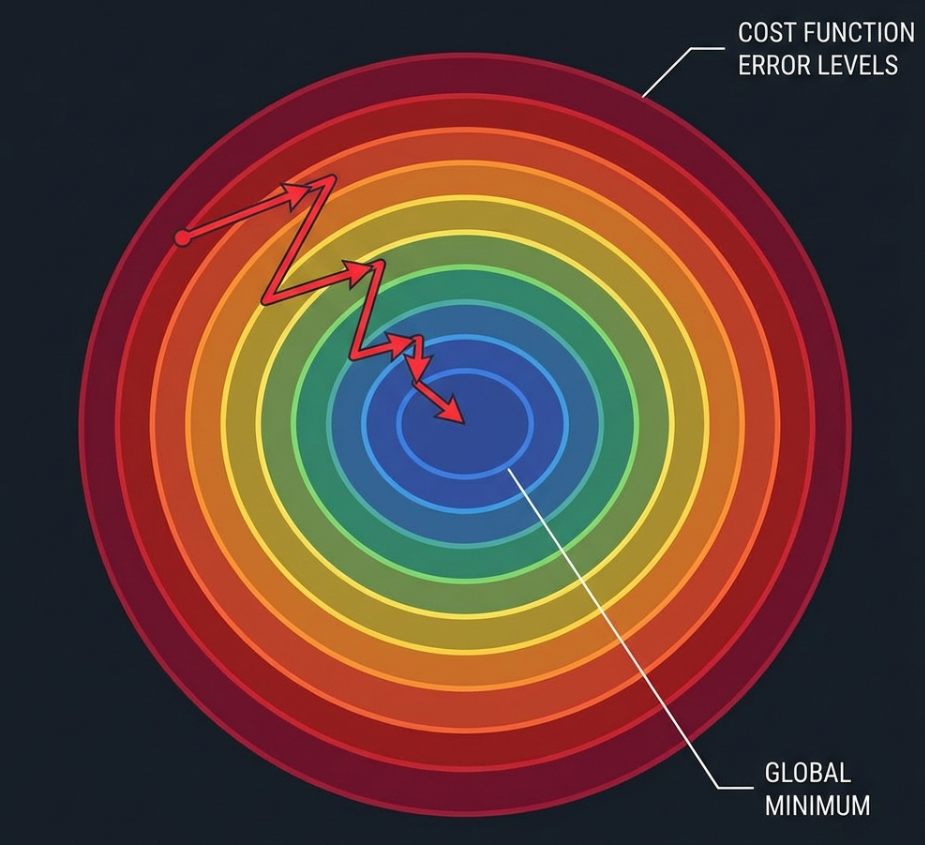

### Gradient Descent for Linear Regression ($y = mx + b$)

**1. The Cost/Error Function (Mean Squared Error)**
We measure how far our predictions are from the actual values using the MSE formula:
$$J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (mx_i + b))^2$$
*Explanation: This calculates the average of the squared differences between actual $y$ and predicted $y$. Our goal is to minimize this value.*

**2. The Gradients (Partial Derivatives)**
To find the direction to move, we calculate the slope of the cost function / error function with respect to $m$ and $b$:
$$\frac{\partial J}{\partial m} = -\frac{2}{n} \sum_{i=1}^{n} x_i(y_i - (mx_i + b))$$
$$\frac{\partial J}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - (mx_i + b))$$
*Explanation: These formulas tell us how much the error changes if we nudge $m$ or $b$. A positive gradient means the error increases, so we move in the opposite direction.*

**3. The Update Rule**
We update the values of $m$ and $b$ iteratively:
$$m = m - \alpha \cdot \frac{\partial J}{\partial m}$$
$$b = b - \alpha \cdot \frac{\partial J}{\partial b}$$
*Explanation: We subtract a small portion (defined by the learning rate $\alpha$) of the gradient from our current values to "step down" the hill toward the minimum error.*

**Component Meanings:**
*   $n$: Total number of data points in the dataset.
*   $x_i$: The input value (feature) for the $i$-th observation.
*   $y_i$: The actual target value for the $i$-th observation.
*   $m$: The slope (weight) of the regression line.
*   $b$: The y-intercept (bias) of the regression line.
*   $\alpha$ (Alpha): The **Learning Rate**, a small positive number that determines the step size at each iteration.
    *   **Finding $\alpha$:** Since there is no universal formula, $\alpha$ is a **hyperparameter** typically found through trial and error (hyperparameter tuning). Common practice involves testing values like $0.1, 0.01, 0.001,$ or $0.0001$ to find a balance between convergence speed and stability.
*   $\frac{\partial J}{\partial m}, \frac{\partial J}{\partial b}$: The **Gradients**, representing the direction and magnitude of the steepest increase in error.


**The Symbol $\partial$ (Partial Derivative):**
*   The symbol $\partial$ (often called "del") represents a **partial derivative**.
*   In $\frac{\partial J}{\partial m}$, it indicates that we are calculating the derivative of the cost function $J$ with respect to $m$ while treating all other variables (like $b$) as constants.
*   It measures how sensitive the total error is to changes in that specific parameter alone.




You might wonder why there is a **2** in the formula, or where the **minus sign** comes from. It all comes from **Calculus (The Chain Rule)** applied to our error.
Here is the step-by-step breakdown:

#### 1. Why do we start with Squared Error?
We defined our single error for one point as:
$$Error = (Actual - Predicted)^2 = (y - (mx + b))^2$$

*   **Why square it?**
    1.  It removes negative signs (error is always positive).
    2.  It punishes big errors more than small ones.
    3.  **Crucially:** It is very easy to find the derivative of a square!

#### 2. The "Magic" of Calculus (The Derivative)
To find the gradient, we ask: *"How does this Error change if we wiggle $m$?"*
We use the **Power Rule** from calculus:
*   $\frac{d}{dx}(u^2) = 2 \cdot u \cdot u'$
*   In English: Bring the 2 down, keep the inside the same, then multiply by the derivative of the inside.

#### 3. Deriving the Gradient for $m$ (Slope)
Let's apply that Power Rule to our error $(y - (mx + b))^2$:
1.  **The Outer Part (The Square):**
    Bring the 2 down.
    $$ \rightarrow 2 \cdot (y - (mx + b)) $$
2.  **The Inner Part (The Chain Rule):**
    Look inside the brackets: $y - mx - b$. What is attached to $m$?
    It is **$-x$**. (This is the derivative of the inside with respect to $m$).
3.  **Combine them:**
    $$ 2 \cdot (y - (mx + b)) \cdot (-x) $$
    $$ = -2x(y - (mx + b)) $$
4.  **Average it (FINDING $m$):**
    Since we have $n$ points, we sum them all up and divide by $n$:
    $$ \frac{\partial J}{\partial m} = -\frac{2}{n} \sum x(y - (mx + b)) $$

#### 4. Deriving the Gradient for $b$ (Intercept)
We do the exact same logic for $b$:
1.  **The Outer Part:** Same as above.
    $$ \rightarrow 2 \cdot (y - (mx + b)) $$
2.  **The Inner Part:**
    Look inside $y - mx - b$. What is attached to $b$?
    It is acts like $-1b$, so the derivative is just **$-1$**.
3.  **Combine them:**
    $$ 2 \cdot (y - (mx + b)) \cdot (-1) $$
    $$ = -2(y - (mx + b)) $$
4.  **Average it (FINDING $b$):**
    Sum them up and divide by $n$:
    $$ \frac{\partial J}{\partial b} = -\frac{2}{n} \sum (y - (mx + b)) $$

### Why is there a (-1) here?
The **-1** is the **Derivative of the Inner Function** with respect to $b$.
If we look inside the brackets:
$$ \text{Inner} = y - mx - b $$
When calculating $\frac{\partial}{\partial b}$ (how this changes when $b$ changes):
1.  **$y$** is treated as a constant $\rightarrow$ derivative is **0**.
2.  **$-mx$** is treated as a constant $\rightarrow$ derivative is **0**.
3.  **$-b$** is our variable. This is really $-1 \cdot b$.
    *   The derivative of $-1b$ is just **-1**.
So, according to the Chain Rule, we must multiply the whole equation by this **-1**.

#### Quick Component Summary
| Component | Where it came from | Meaning |
| :--- | :--- | :--- |
| **Squared $(\dots)^2$** | The definition of MSE | We chose this to make math easy and handle negatives. |
| **The number $2$** | From the Power Rule | When you differentiate $x^2$, you get $2x$. |
| **The minus $(-)$** | From the "Predicted" term | Our formula is $y - \hat{y}$. Since the variable ($m$ or $b$) is being *subtracted*, a minus sign pops out. |
| **The $x$ term** | From the Line Equation | In $mx$, the $m$ is multiplied by $x$. So when finding the effect of $m$, the $x$ stays. |
| **Sum $\sum$ & $\frac{1}{n}$** | Statistics | We don't want the error for just one point; we want the **average** error for the whole dataset. |

## Why multiply by $-x$ for $m$, but only $-1$ for $b$?
It comes down to the **Chain Rule** in calculus. When we take the "derivative of the inside", we have to look at what represents the coefficient (what is attached) of the variable we are changing.
The term inside our squared error is:
$$ \text{Inner Term} = y - (mx + b) = y - mx - b $$

### 1. For the Slope ($m$): The $x$ matters
We focus effectively on the term: **$-mx$**
Since we are deriving with respect to $m$, the $x$ acts like a constant multiplier.
*   *Analogy:* If you differentiate $-5m$, you get $-5$.
*   Here, $x$ is the "5". So differentiating $-xm$ gives **$-x$**.
*   **Result:** We include this **$-x$** in the multiplication.

### 2. For the Intercept ($b$): The $x$ disappears
We focus effectively on the term: **$-b$**
This is effectively **$-1 \cdot b$**. The $x$ is not attached to $b$ at all, so it is treated as zero.
*   *Analogy:* If you differentiate $-1b$, you get $-1$.
*   **Result:** We multiply simply by **$-1$** (which is why there is no $x$ in the $b$ gradient formula).

### Summary Table
| Variable | The "Inside" Term | What is attached? (Coefficient) | Derivative of Inside |
| :--- | :--- | :--- | :--- |
| **$m$** (Slope) | $- \mathbf{m} \cdot x$ | $-x$ is attached | **$-x$** |
| **$b$** (Intercept) | $- \mathbf{b}$ | $-1$ is attached | **$-1$** |

---
---

# Derivation of the Intercept ($b$) in Linear Regression

In machine learning, we use **Simple Linear Regression** to model the relationship between an input variable $x$ and an output variable $y$.

### The Linear Model
The prediction equation is defined as:
$$y' = mx + b$$

Where:
* $y'$ = Predicted value 
    * $y' = w_1x_1 + w_2x_2 + ... + w_dx_d + b$
* $m$ = Slope (Weight)
* $x$ = Input feature
* $b$ = Intercept (Bias)



$$J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y'_i - y_i)^2$$

Substituting the model ($mx_i + b$) for $y'_i$:

$$J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (mx_i + b - y_i)^2$$


$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(mx_i + b - y_i)^{2-1} \cdot \frac{\partial}{\partial b}(mx_i + b - y_i)$$

For the Intercept ($b$):
- We treat $mx_i$ and $y_i$ as constants.
- The derivative of $(mx_i + b - y_i)$ with respect to $b$ is $1$.
- Therefore, the final gradient is simply $\frac{2}{n} \sum (y'_i - y_i)$.

$$\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (mx_i + b - y_i)$$


$$\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (y'_i - y_i)$$


In an ML algorithm, the intercept is updated iteratively using a **learning rate** ($\alpha$):

$$b_{new} = b_{old} - \alpha \cdot \frac{\partial J}{\partial b}$$

Substituting our derivation:

$$b = b - \alpha \left[ \frac{2}{n} \sum_{i=1}^{n} (y'_i - y_i) \right]$$




---
---
---

# Derivation of the Weights ($m_j$) for Multiple Linear Regression

In a multiple feature scenario, each input feature $x_j$ has a corresponding weight $m_j$. To optimize the model, we must find the gradient for each individual weight.

The prediction $y'$ is the sum of all weighted features plus the bias:
$$y' = m_1x_1 + m_2x_2 + ... + m_jx_j + ... + m_dx_d + b$$

In summation notation for the $i$-th observation:

The $m_j x_{ij}$ refers to the $i$ th point of feature $j$ of slope $j$
$$y'_i = \sum_{j=1}^{d} m_j x_{ij} + b$$



### The Cost Function (MSE)
We use the Mean Squared Error to measure performance:
$$J(\mathbf{m}, b) = \frac{1}{n} \sum_{i=1}^{n} (y'_i - y_i)^2$$

Substituting the model expression:
$$J(\mathbf{m}, b) = \frac{1}{n} \sum_{i=1}^{n} \left( \left( \sum_{j=1}^{d} m_j x_{ij} + b \right) - y_i \right)^2$$


$$\frac{\partial J}{\partial m_j} = \frac{1}{n} \sum_{i=1}^{n} 2\left( \sum_{j=1}^{d} m_j x_{ij} + b - y_i \right) \cdot \frac{\partial}{\partial m_j}\left( \sum_{j=1}^{d} m_j x_{ij} + b - y_i \right)$$


When differentiating the inside with respect to $m_j$:
* The terms for all other weights ($m_1, m_2$, etc.) are treated as constants $\rightarrow 0$.
* The term $m_j x_{ij}$ derived with respect to $m_j$ results in $\rightarrow x_{ij}$.
    * Here we are doing partial differentiation of $m_j$
* The intercept $b$ and actual value $y_i$ are constants $\rightarrow 0$.

Therefore, the inner derivative is **$x_{ij}$**.


$$\frac{\partial J}{\partial m_j} = \frac{2}{n} \sum_{i=1}^{n} \left( \sum_{j=1}^{d} m_j x_{ij} + b - y_i \right) \cdot x_{ij}$$

Replacing the inner sum with the prediction symbol $y'_i$:

$$\frac{\partial J}{\partial m_j} = \frac{2}{n} \sum_{i=1}^{n} (y'_i - y_i)x_{ij}$$




Each weight $m_j$ is updated by subtracting the product of the learning rate ($\alpha$) and its specific gradient:

$$m_j = m_j - \alpha \cdot \frac{\partial J}{\partial m_j}$$

$$\text{New Weight or New Slope} = \text{Old Slope} - \text{Step Size} (\text{Direction})$$

Substituting our derived gradient:

$$m_j = m_j - \alpha \left[ \frac{2}{n} \sum_{i=1}^{n} (y'_i - y_i)x_{ij} \right]$$